## FASE 0 — Setup Environment
---

In [1]:
import torch, cv2, ultralytics, mediapipe, albumentations, os
from pathlib import Path

print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'OpenCV      : {cv2.__version__}')
print(f'Ultralytics : {ultralytics.__version__}')

PyTorch     : 2.5.1+cu121
CUDA        : True
GPU         : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM        : 4.3 GB
OpenCV      : 4.13.0
Ultralytics : 8.4.37


In [2]:
import os
BASE_DIR = os.getcwd()

DIRS = {
    'raw_nitymed'   : f'{BASE_DIR}/raw_data/nitymed',
    'raw_mrl'       : f'{BASE_DIR}/raw_data/mrl',
    'raw_roboflow'  : f'{BASE_DIR}/raw_data/roboflow',
    'frames_nitymed': f'{BASE_DIR}/frames/nitymed',
    'dataset_train' : f'{BASE_DIR}/dataset_v3/images/train',
    'dataset_val'   : f'{BASE_DIR}/dataset_v3/images/val',
    'dataset_test'  : f'{BASE_DIR}/dataset_v3/images/test',
    'labels_train'  : f'{BASE_DIR}/dataset_v3/labels/train',
    'labels_val'    : f'{BASE_DIR}/dataset_v3/labels/val',
    'labels_test'   : f'{BASE_DIR}/dataset_v3/labels/test',
    'models'        : f'{BASE_DIR}/models',
    'exports'       : f'{BASE_DIR}/exports',
    'logs'          : f'{BASE_DIR}/logs',
}
for _, p in DIRS.items():
    os.makedirs(p, exist_ok=True)
print('Direktori v3 siap.')


Direktori v3 siap.


In [3]:
CONFIG = {
    'roboflow_api_key'   : 'YOUR_ROBOFLOW_API_KEY',
    'roboflow_workspace' : 'linhne',
    'roboflow_project'   : 'drowsiness-detection-xditz',
    'roboflow_version'   : 5,
    'grok_api_key'       : 'YOUR_GROK_API_KEY',
    'grok_model'         : 'grok-beta',
    'model_size'         : 'yolo11n.pt',
    'epochs'             : 100,
    'batch_size'         : 16,
    'image_size'         : 640,  # FIX: 640 untuk full-frame detection
    'patience'           : 30,
    'learning_rate'      : 0.001,
    'workers'            : 4,
    'fps'                : 30,
    'perclos_window_sec' : 60,
    'perclos_lvl1'       : 0.50,
    'perclos_lvl2'       : 0.70,
    'perclos_lvl3'       : 0.85,
    'nitymed_fps_extract': 5,
    'train_ratio'        : 0.70,
    'val_ratio'          : 0.20,
    'test_ratio'         : 0.10,
    'class_names'        : ['eye_open', 'eye_closed'],
}
print('CONFIG dimuat.')

CONFIG dimuat.


## FASE 1 — Persiapan Dataset
---

In [28]:
# ============================================================
# FASE 1-A: Ekstraksi Frame NITYMed
# Auto-skip frame yang sudah ada — bisa dilanjut jika terputus
# ============================================================
import cv2, os
from pathlib import Path
from tqdm import tqdm

def extract_frames(video_path, output_dir, target_fps=5, label='unknown'):
    os.makedirs(output_dir, exist_ok=True)
    cap  = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return 0
    vfps = cap.get(cv2.CAP_PROP_FPS)
    skip = max(1, int(vfps / target_fps))
    name = Path(video_path).stem
    fc, saved = 0, 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if fc % skip == 0:
            fp = os.path.join(output_dir, f'{label}_{name}_f{fc:05d}.jpg')
            if not os.path.exists(fp):  # Skip jika sudah ada
                cv2.imwrite(fp, frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
                saved += 1
        fc += 1
    cap.release()
    return saved

def process_nitymed(root, out_dir, fps=5):
    stats = {}
    for cat in ['Yawning', 'Microsleep']:
        cat_path  = os.path.join(root, cat)
        if not os.path.exists(cat_path):
            print(f'Folder {cat} tidak ditemukan'); continue
        videos    = list(Path(cat_path).glob('*.mp4'))
        out_sub   = os.path.join(out_dir, cat.lower())
        existing  = len(list(Path(out_sub).glob('*.jpg'))) if os.path.exists(out_sub) else 0
        print(f'{cat}: {len(videos)} video | {existing} frame sudah ada di Drive')
        total = 0
        for vp in tqdm(videos, desc=f'  {cat}'):
            total += extract_frames(str(vp), out_sub, fps, cat.lower())
        stats[cat] = total
        print(f'  Baru diekstrak: {total} frame')
    return stats

if os.path.exists(DIRS['raw_nitymed']) and any(Path(DIRS['raw_nitymed']).iterdir()):
    stats = process_nitymed(DIRS['raw_nitymed'], DIRS['frames_nitymed'],
                              CONFIG['nitymed_fps_extract'])
else:
    print('Upload video NITYMed ke:', DIRS['raw_nitymed'])


Yawning: 107 video | 0 frame sudah ada di Drive


  Yawning: 100%|█████████████████████████████████████████████████████████████████████| 107/107 [05:10<00:00,  2.90s/it]


  Baru diekstrak: 17685 frame
Microsleep: 19 video | 0 frame sudah ada di Drive


  Microsleep: 100%|████████████████████████████████████████████████████████████████████| 19/19 [03:31<00:00, 11.14s/it]

  Baru diekstrak: 11666 frame


### LOAD FRAMES — Skip ekstraksi, pakai frame yang sudah ada


In [4]:
# ============================================================
# LOAD FRAMES 
# Jalankan ini sebagai PENGGANTI Fase 1-A jika frame sudah ada
# Hemat 30-90 menit tidak perlu ekstrak ulang
# ============================================================
import os
from pathlib import Path

print('Memeriksa frame di Google Drive...')
print(f'Path: {DIRS["frames_nitymed"]}\n')

FRAME_SUMMARY = {}
total_frames  = 0

if os.path.exists(DIRS['frames_nitymed']):
    for cat_folder in sorted(Path(DIRS['frames_nitymed']).iterdir()):
        if not cat_folder.is_dir(): continue
        frames = list(cat_folder.glob('*.jpg')) + list(cat_folder.glob('*.png'))
        n      = len(frames)
        FRAME_SUMMARY[cat_folder.name] = {'count': n, 'path': str(cat_folder)}
        total_frames += n
        status = 'OK' if n > 0 else 'KOSONG'
        print(f'  [{status}] {cat_folder.name:<15}: {n:>6} frame')

print(f'\nTotal frame tersedia: {total_frames}')
if total_frames > 0:
    print('Frame siap. Lanjut ke LOAD ANNOTATIONS atau Fase 1-D.')
else:
    print('Belum ada frame. Jalankan Fase 1-A terlebih dahulu.')


Memeriksa frame di Google Drive...
Path: C:\Users\ACER\drowsy_detection/frames/nitymed

  [OK] microsleep     :  11666 frame
  [OK] yawning        :  17685 frame

Total frame tersedia: 29351
Frame siap. Lanjut ke LOAD ANNOTATIONS atau Fase 1-D.


### iMAGE PROCESSING & ANOTASI


In [ ]:
# ============================================================
# FASE 1-D FIXED v3: Anotasi dengan arsitektur BENAR
#
# ARSITEKTUR YANG BENAR:
# Input training: FULL FRAME (640x640 grayscale)
# Label: class cx cy bw bh — semua relatif ke full frame
# YOLO belajar: deteksi dan klasifikasi area mata di full frame
#
# DEAD ZONE EAR: skip frame dengan EAR ambiguous (0.20-0.28)
# untuk mengurangi label yang salah karena noise/kacamata
# ============================================================

import os, math, warnings, cv2, numpy as np
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'
import mediapipe as mp
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

mp_face_mesh = mp.solutions.face_mesh

LEFT_EAR_IDX  = [33, 160, 158, 133, 153, 144]
RIGHT_EAR_IDX = [362, 385, 387, 263, 373, 380]

# EAR thresholds
EAR_CLOSED   = 0.20   # Di bawah ini pasti closed
EAR_OPEN     = 0.28   # Di atas ini pasti open
# Zone 0.20-0.28 = AMBIGUOUS → SKIP (jangan latih dengan label yang meragukan)


def enhance_dark_frame(img_bgr):
    """CLAHE + adaptive brightness untuk frame gelap."""
    gray_mean = np.mean(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY))
    result    = img_bgr.copy()

    # CLAHE di ruang LAB
    lab = cv2.cvtColor(result, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    result = cv2.cvtColor(cv2.merge([clahe.apply(l),a,b]), cv2.COLOR_LAB2BGR)

    # Brightness boost jika masih gelap
    mean_after = np.mean(cv2.cvtColor(result, cv2.COLOR_BGR2GRAY))
    if mean_after < 60:
        alpha = min(90 / max(mean_after, 1), 2.5)
        result = cv2.convertScaleAbs(result, alpha=alpha, beta=15)
    return result


def compute_ear(lm, indices):
    pts = [np.array([lm[i].x, lm[i].y]) for i in indices]
    v1  = np.linalg.norm(pts[1]-pts[5])
    v2  = np.linalg.norm(pts[2]-pts[4])
    h   = np.linalg.norm(pts[0]-pts[3])
    return (v1+v2)/(2.0*h) if h > 0 else 0.0


def roi_correction(lm, w, h, pad=10):
    """Algorithm 1 dari jurnal Florez et al. (2024)."""
    def px(i): return int(lm[i].x * w)
    def py(i): return int(lm[i].y * h)
    def pt(i): return (px(i), py(i))
    def dist(a, b): return int(math.sqrt((a[0]-b[0])**2+(a[1]-b[1])**2))

    xa, ya = px(336), py(336)
    xb, yb = px(63),  py(63)
    d1 = dist(pt(63),pt(117)); d2 = dist(pt(63),pt(107))
    d3 = dist(pt(336),pt(293)); d4 = dist(pt(293),pt(346))

    start_x = xb if xa > xb else xa
    end_x   = (xa+d3) if xa > xb else (xb+d2)
    start_y = yb if ya > yb else ya
    end_y   = (ya+d4) if ya > yb else (yb+d1)

    if (end_x-start_x) <= 10 or (end_y-start_y) >= h:
        return None
    return (max(0,start_x-pad), max(0,start_y-pad),
            min(w,end_x+pad),   min(h,end_y+pad))


def annotate_full_frame_v3(image_dir, output_img_dir, output_lbl_dir,
                            resume=True, out_size=640):
    """
    Anotasi yang BENAR untuk YOLO object detection.

    Yang disimpan:
    - Image : full frame, resize ke out_size x out_size, grayscale 3ch
    - Label : class cx cy bw bh  (semua relatif ke full frame out_size)

    Dead zone EAR: frame dengan EAR 0.20-0.28 di-SKIP
    karena labelnya tidak dapat dipercaya (ambiguous zone).
    """
    os.makedirs(output_img_dir, exist_ok=True)
    os.makedirs(output_lbl_dir, exist_ok=True)

    imgs = list(Path(image_dir).glob('*.jpg')) + \
           list(Path(image_dir).glob('*.png'))

    if resume:
        done = {p.stem for p in Path(output_lbl_dir).glob('*.txt')}
        todo = [p for p in imgs if p.stem not in done]
        if done:
            print(f'  Resume: {len(done)} selesai, {len(todo)} tersisa')
    else:
        todo = imgs

    if not todo:
        print(f'  Semua {len(imgs)} sudah teranotasi!'); return

    face_mesh = mp_face_mesh.FaceMesh(
        static_image_mode=True, max_num_faces=1,
        refine_landmarks=True, min_detection_confidence=0.45
    )

    stats = {'ok':0,'no_face':0,'ambiguous':0,'no_roi':0,
             'open':0,'closed':0,'enhanced':0}

    for img_path in tqdm(todo, desc=Path(image_dir).name):
        img = cv2.imread(str(img_path))
        if img is None: stats['no_face']+=1; continue

        h_orig, w_orig = img.shape[:2]

        # Enhancement untuk frame gelap
        gray_mean = np.mean(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
        if gray_mean < 80:
            img_proc = enhance_dark_frame(img)
            stats['enhanced'] += 1
        else:
            img_proc = img

        # MediaPipe deteksi wajah (pakai RGB)
        rgb     = cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb)
        if not results.multi_face_landmarks:
            stats['no_face']+=1; continue

        lm = results.multi_face_landmarks[0].landmark

        # EAR — dengan dead zone untuk label yang ambiguous
        ear_l   = compute_ear(lm, LEFT_EAR_IDX)
        ear_r   = compute_ear(lm, RIGHT_EAR_IDX)
        avg_ear = (ear_l + ear_r) / 2

        if EAR_CLOSED < avg_ear < EAR_OPEN:
            # Dead zone: EAR tidak bisa dipercaya untuk labeling
            # Skip frame ini daripada melatih dengan label salah
            stats['ambiguous']+=1; continue

        label = 1 if avg_ear <= EAR_CLOSED else 0  # 1=closed, 0=open

        # ROI Correction Algorithm 1 — koordinat di frame ORIGINAL
        roi = roi_correction(lm, w_orig, h_orig, pad=10)
        if roi is None: stats['no_roi']+=1; continue

        x1, y1, x2, y2 = roi

        # ─────────────────────────────────────────
        # FIX KRITIS: Bbox relatif ke FULL FRAME
        # bukan relatif ke crop!
        # ─────────────────────────────────────────
        cx = ((x1+x2)/2) / w_orig   # relatif ke full frame
        cy = ((y1+y2)/2) / h_orig
        bw = (x2-x1)     / w_orig
        bh = (y2-y1)     / h_orig

        if bw <= 0.01 or bh <= 0.005: stats['no_roi']+=1; continue

        # ─────────────────────────────────────────
        # FIX KRITIS: Simpan FULL FRAME (bukan crop)
        # Resize ke out_size x out_size, grayscale 3ch
        # ─────────────────────────────────────────
        gray3   = cv2.merge([cv2.cvtColor(img_proc, cv2.COLOR_BGR2GRAY)]*3)
        img_out = cv2.resize(gray3, (out_size, out_size))

        # Simpan gambar FULL FRAME
        cv2.imwrite(f'{output_img_dir}/{img_path.stem}.jpg', img_out,
                    [cv2.IMWRITE_JPEG_QUALITY, 90])
        # Simpan label — int, bukan float
        with open(f'{output_lbl_dir}/{img_path.stem}.txt', 'w') as f:
            f.write(f'{label} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')

        stats['ok']+=1
        if label==0: stats['open']  +=1
        else:        stats['closed']+=1

    face_mesh.close()

    total = len(todo)
    print(f'\n  Selesai   : {stats["ok"]}/{total} ({stats["ok"]/max(total,1)*100:.1f}%)')
    print(f'  eye_open  : {stats["open"]:>6}')
    print(f'  eye_closed: {stats["closed"]:>6}')
    print(f'  no_face   : {stats["no_face"]:>6}')
    print(f'  ambiguous : {stats["ambiguous"]:>6} (di-skip, EAR 0.20-0.28)')
    print(f'  enhanced  : {stats["enhanced"]:>6}')
    print(f'  roi_error : {stats["no_roi"]:>6}')


# ── HAPUS dataset_v3 lama jika ada ──
import shutil
ann_v3 = os.path.join(BASE_DIR, 'annotations_v3')
if os.path.exists(ann_v3):
    ans = input(f'Hapus {ann_v3} dan mulai ulang? (y/n): ')
    if ans.lower() == 'y':
        shutil.rmtree(ann_v3)
        print('Dihapus.')

# ── JALANKAN ──
for category in ['microsleep', 'yawning']:
    img_dir  = os.path.join(DIRS['frames_nitymed'], category)
    out_imgs = os.path.join(BASE_DIR, f'annotations_v3/{category}/images')
    out_lbls = os.path.join(BASE_DIR, f'annotations_v3/{category}/labels')

    if os.path.exists(img_dir) and any(Path(img_dir).glob('*.jpg')):
        print(f'\n[Fase 1-D v3] {category}')
        annotate_full_frame_v3(
            image_dir      = img_dir,
            output_img_dir = out_imgs,
            output_lbl_dir = out_lbls,
            resume         = True,
            out_size       = 640
        )
    else:
        print(f'Folder {category} kosong, skip.')



[Fase 1-D v3] microsleep


microsleep: 100%|████████████████████████████████████████████████████████████████| 11666/11666 [08:46<00:00, 22.17it/s]



  Selesai   : 10576/11666 (90.7%)
  eye_open  :   9045
  eye_closed:   1531
  no_face   :    200
  ambiguous :    890 (di-skip, EAR 0.20-0.28)
  enhanced  :  11665
  roi_error :      0

[Fase 1-D v3] yawning


yawning:  36%|████████████████████████▍                                           | 6341/17685 [04:53<08:41, 21.76it/s]

### LOAD ANNOTATIONS — Skip anotasi, pakai label yang sudah ada


In [5]:
# ============================================================
# LOAD ANNOTATIONS (BOUNDING BOX)
# Jalankan sebagai PENGGANTI Fase 1-D jika label sudah ada
# ============================================================
import os
from pathlib import Path

print('Memeriksa anotasi bounding box (v3) di Google Drive...\n')
ANNOTATION_SUMMARY = {}
total_labels = 0
total_images = 0

for cat in ['microsleep', 'yawning']:
    img_dir = os.path.join(DIRS['frames_nitymed'], cat)
    
    # PERBAIKAN KRITIS: Menyesuaikan dengan struktur folder v3 yang dihasilkan oleh Fase 1-D v3
    lbl_dir = os.path.join(BASE_DIR, f'annotations_v3/{cat}/labels')
    img_out_dir = os.path.join(BASE_DIR, f'annotations_v3/{cat}/images') # Menambahkan pengecekan gambar output
    
    n_imgs_raw = len(list(Path(img_dir).glob('*.jpg'))) if os.path.exists(img_dir) else 0
    n_lbls     = len(list(Path(lbl_dir).glob('*.txt'))) if os.path.exists(lbl_dir) else 0
    n_imgs_out = len(list(Path(img_out_dir).glob('*.jpg'))) if os.path.exists(img_out_dir) else 0
    
    cov = (n_lbls / n_imgs_raw) * 100 if n_imgs_raw > 0 else 0
    icon = 'OK' if cov >= 70 else ('PARTIAL' if cov > 0 else 'EMPTY')
    
    print(f'  [{icon}] {cat:<15}: {n_lbls:>6} label / {n_imgs_raw:>6} raw frame ({cov:.1f}% coverage)')
    
    # Validasi kesesuaian jumlah label dan gambar output
    if n_lbls != n_imgs_out:
        print(f"    -> PERINGATAN: Jumlah label ({n_lbls}) tidak sama dengan jumlah gambar output ({n_imgs_out}).")
        print("    -> Kemungkinan proses anotasi terputus atau tidak selesai sempurna.")

    ANNOTATION_SUMMARY[cat] = {
        'img_dir': img_dir,
        'lbl_dir': lbl_dir,
        'img_out_dir': img_out_dir,
        'n_imgs_raw': n_imgs_raw,
        'n_imgs_out': n_imgs_out,
        'n_labels': n_lbls,
        'coverage': cov
    }
    total_labels += n_lbls
    total_images += n_imgs_out

print(f'\nTotal label valid v3  : {total_labels}')
print(f'Total gambar valid v3 : {total_images}')

if total_labels > 0:
    print('Anotasi v3 siap. Lanjut ke Fase 2-A (Unifikasi).')
else:
    print('Belum ada anotasi v3. Jalankan Fase 1-D terlebih dahulu.')

Memeriksa anotasi bounding box (v3) di Google Drive...

  [OK] microsleep     :  10576 label /  11666 raw frame (90.7% coverage)
  [OK] yawning        :  16052 label /  17685 raw frame (90.8% coverage)

Total label valid v3  : 26628
Total gambar valid v3 : 26628
Anotasi v3 siap. Lanjut ke Fase 2-A (Unifikasi).


Distribusi anotasi v3:
  class 0 (eye_open): 23993
  class 1 (eye_closed): 2635


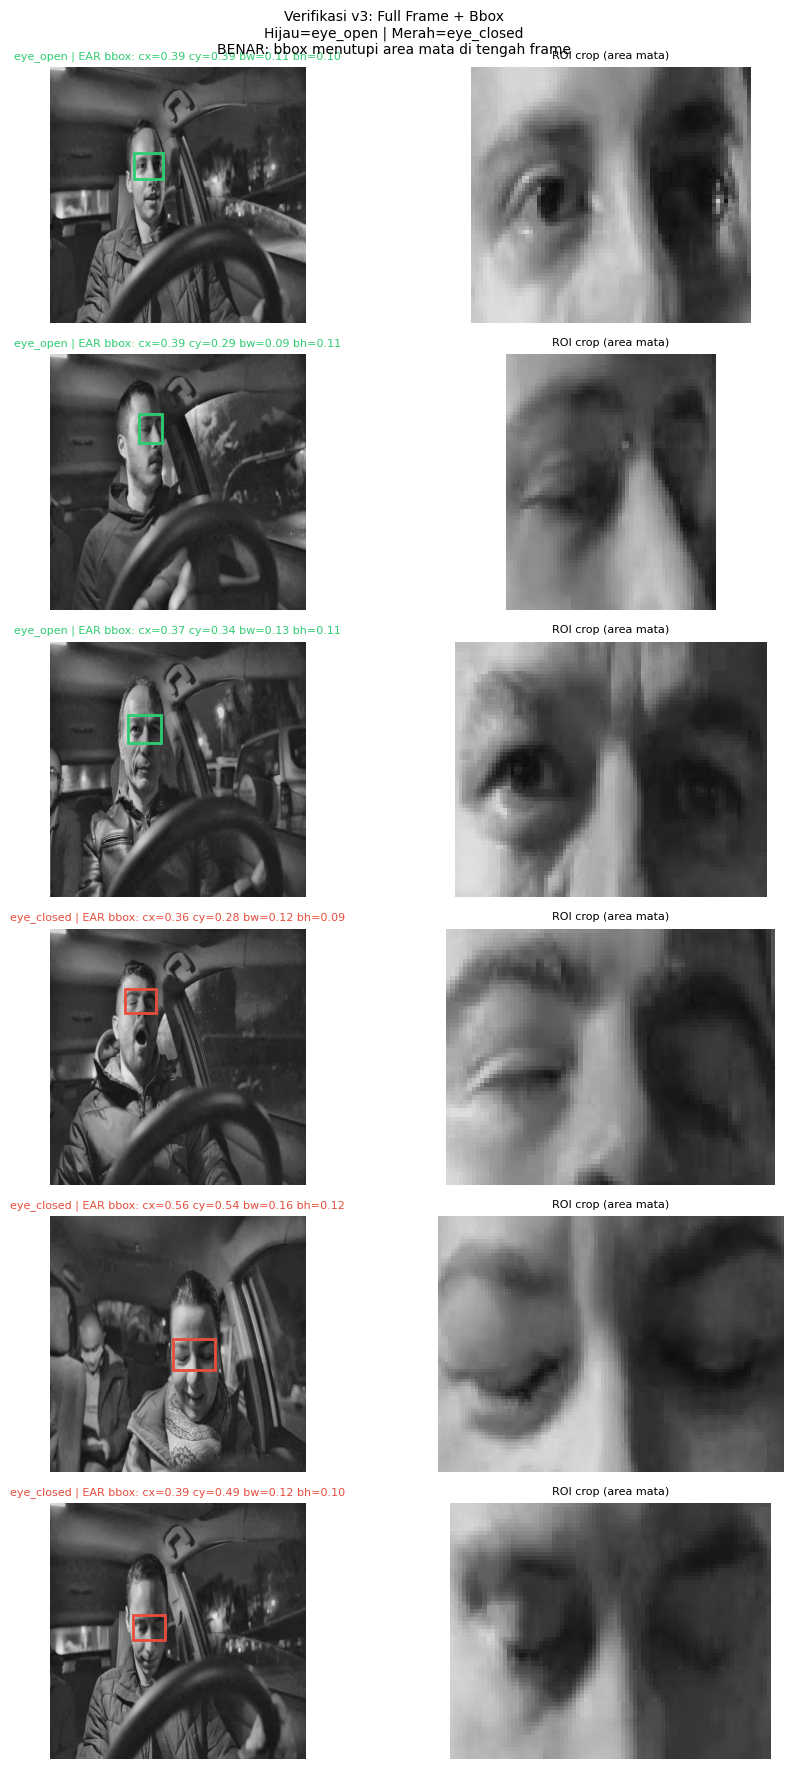

Tersimpan: C:\Users\ACER\drowsy_detection\verify_v3.png

Cek: apakah bbox di kolom kiri menutupi area MATA di tengah frame?
      Kolom kanan harus menampilkan crop yang berisi mata/area mata.


In [7]:
# ============================================================
# VERIFIKASI: Pastikan bbox ada di posisi yang benar di full frame
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2, os, random
from pathlib import Path

def verify_annotations_v3(ann_dir_base, n_per_class=3):
    """
    Verifikasi anotasi v3:
    - Tampilkan full frame 640x640
    - Gambar bbox di posisi yang seharusnya
    - Pastikan bbox menutupi area MATA di tengah frame
    - Crop ROI dari bbox dan tampilkan di sebelah kanan
    """
    COLORS = {0:'#2ECC71', 1:'#E74C3C'}
    NAMES  = ['eye_open', 'eye_closed']

    # Kumpulkan dari semua kategori
    all_pairs = []
    for cat in ['microsleep', 'yawning']:
        idir = Path(ann_dir_base)/cat/'images'
        ldir = Path(ann_dir_base)/cat/'labels'
        if not idir.exists(): continue
        for ip in list(idir.glob('*.jpg')):
            lp = ldir/(ip.stem+'.txt')
            if lp.exists():
                all_pairs.append((ip, lp))

    # Pisah per kelas
    by_cls = {0:[], 1:[]}
    for ip, lp in all_pairs:
        line = open(lp).readline().strip()
        if not line: continue
        c = int(float(line.split()[0]))  # FIX: int(float())
        if c in by_cls: by_cls[c].append((ip, lp))

    print('Distribusi anotasi v3:')
    for c, pairs in by_cls.items():
        print(f'  class {c} ({NAMES[c]}): {len(pairs)}')

    # Sample per kelas
    samples = []
    for c in [0, 1]:
        n = min(n_per_class, len(by_cls[c]))
        samples += [(ip, lp, c) for ip, lp in random.sample(by_cls[c], n)]

    if not samples: print('Tidak ada sampel.'); return

    fig, axes = plt.subplots(len(samples), 2,
                              figsize=(10, len(samples)*3))
    if len(samples) == 1: axes = [axes]

    for i, (ip, lp, gt_cls) in enumerate(samples):
        img = cv2.imread(str(ip))
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Parse label
        line  = open(lp).readline().strip().split()
        c     = int(float(line[0]))
        cx, cy, bw, bh = [float(x) for x in line[1:]]

        # Konversi ke pixel
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        bw_px = int(bw * w)
        bh_px = int(bh * h)

        # Tampilkan full frame + bbox
        axes[i][0].imshow(img_rgb)
        rect = mpatches.Rectangle((x1, y1), bw_px, bh_px,
            linewidth=2, edgecolor=COLORS.get(c,'y'), facecolor='none')
        axes[i][0].add_patch(rect)
        axes[i][0].set_title(
            f'{NAMES[c]} | EAR bbox: cx={cx:.2f} cy={cy:.2f} '
            f'bw={bw:.2f} bh={bh:.2f}',
            fontsize=8, color=COLORS.get(c,'y'))
        axes[i][0].axis('off')

        # Tampilkan crop ROI
        x2 = x1+bw_px; y2 = y1+bh_px
        x1c = max(0,x1); y1c = max(0,y1)
        x2c = min(w,x2); y2c = min(h,y2)
        crop = img_rgb[y1c:y2c, x1c:x2c]
        if crop.size > 0:
            axes[i][1].imshow(crop)
            axes[i][1].set_title('ROI crop (area mata)', fontsize=8)
        axes[i][1].axis('off')

    plt.suptitle(
        'Verifikasi v3: Full Frame + Bbox\n'
        'Hijau=eye_open | Merah=eye_closed\n'
        'BENAR: bbox menutupi area mata di tengah frame',
        fontsize=10)
    plt.tight_layout()
    save_p = os.path.join(BASE_DIR, 'verify_v3.png')
    plt.savefig(save_p, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: {save_p}')
    print('\nCek: apakah bbox di kolom kiri menutupi area MATA di tengah frame?')
    print('      Kolom kanan harus menampilkan crop yang berisi mata/area mata.')


ann_v3_path = os.path.join(BASE_DIR, 'annotations_v3')
if os.path.exists(ann_v3_path):
    verify_annotations_v3(ann_v3_path, n_per_class=3)
else:
    print('Jalankan Fase 1-D v3 terlebih dahulu.')


## FASE 2 — Unifikasi Dataset ke Format YOLO
---

In [6]:
# ============================================================
# FASE 2-A: Unifikasi NITYMed v3 + Roboflow ke dataset_v3
# ============================================================
import os, shutil, random, concurrent.futures
from pathlib import Path
from tqdm import tqdm
import cv2
random.seed(42)

RF_REMAP = {'open':0,'closed':1,'no_yawn':0,'noyawn':0,'yawn':-1,'yawning':-1}

def fast_copy(args):
    src, dst = args
    if os.path.exists(dst): return
    try: os.link(src, dst)
    except OSError: shutil.copy2(src, dst)

def process_roboflow_v3(rf_dir, out_img, out_lbl, out_size=640):
    """
    Roboflow: gambar sudah crop wajah → pakai sebagai full image.
    Resize ke 640, grayscale 3ch, bbox = full image (0.5 0.5 1.0 1.0).
    """
    os.makedirs(out_img, exist_ok=True)
    os.makedirs(out_lbl, exist_ok=True)
    stats = {0:0,1:0}; skipped = 0

    for split in ['train','valid','test']:
        sp = Path(rf_dir)/split
        if not sp.exists(): continue
        for cf in [d for d in sp.iterdir() if d.is_dir()]:
            key = cf.name.lower().replace(' ','_')
            cid = RF_REMAP.get(key,-1)
            imgs = list(cf.glob('*.jpg'))+list(cf.glob('*.png'))
            if cid==-1: skipped+=len(imgs); continue
            for ip in tqdm(imgs, desc=f'  RF {split}/{cf.name}', leave=False):
                img = cv2.imread(str(ip))
                if img is None: continue
                # Resize + grayscale 3ch
                gray3   = cv2.merge([cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)]*3)
                resized = cv2.resize(gray3, (out_size,out_size))
                ns = f'rf_{split}_{key}_{ip.stem}'
                di = f'{out_img}/{ns}.jpg'
                dl = f'{out_lbl}/{ns}.txt'
                if not os.path.exists(di):
                    cv2.imwrite(di, resized, [cv2.IMWRITE_JPEG_QUALITY,90])
                if not os.path.exists(dl):
                    # Roboflow sudah crop area wajah/mata = full image bbox
                    open(dl,'w').write(f'{cid} 0.500000 0.500000 1.000000 1.000000\n')
                stats[cid]+=1
    print(f'  eye_open={stats[0]} | eye_closed={stats[1]} | skipped={skipped}')
    return stats[0]+stats[1]


def create_balanced_split(all_img, all_lbl, tr=0.70, vr=0.20,
                           max_ratio=5.0, max_open_limit=15000):
    """
    Stratified split dengan optional undersampling majority class.
    max_ratio: rasio maksimal majority:minority yang diizinkan.
    Jika rasio > max_ratio, eye_open di-undersample ke max_ratio * n_closed.
    """
    random.seed(42)
    imgs   = list(Path(all_img).glob('*.jpg'))
    byc    = {0:[], 1:[]}

    for ip in tqdm(imgs, desc='  Scanning', leave=False):
        lp = Path(all_lbl)/(ip.stem+'.txt')
        if not lp.exists(): continue
        line = open(lp).readline().strip()
        if not line: continue
        c = int(float(line.split()[0]))  # FIX: int(float())
        if c in byc: byc[c].append(ip)

    n_open   = len(byc[0])
    n_closed = len(byc[1])
    ratio    = n_open / max(n_closed, 1)

    print(f'\n  Sebelum balancing:')
    print(f'    eye_open  : {n_open}')
    print(f'    eye_closed: {n_closed}')
    print(f'    Rasio     : {ratio:.1f}:1')

    # Undersample eye_open jika rasio terlalu tinggi
    target_open = n_open

    # 1. Evaluasi rasio (mencegah imbalance ekstrem)
    if ratio > max_ratio and n_closed > 0:
        target_open = int(n_closed * max_ratio)
    
    # 2. Evaluasi batas absolut (mencegah data terlalu besar)
    if target_open > max_open_limit:
        target_open = max_open_limit

    # Eksekusi pemotongan jika ukuran target lebih kecil dari aslinya
    if target_open < n_open:
        random.shuffle(byc[0])
        byc[0] = byc[0][:target_open]
        print(f'  Undersample eye_open ke {target_open} (Batas disesuaikan)')

    print(f'  Setelah balancing:')
    for c,imgs2 in byc.items():
        print(f'    class {c}: {len(imgs2)}')

    sp = {'train':[],'val':[],'test':[]}
    for c, imgs2 in byc.items():
        random.shuffle(imgs2)
        n = len(imgs2)
        nt = int(n*tr); nv = int(n*vr)
        sp['train']+=imgs2[:nt]
        sp['val']  +=imgs2[nt:nt+nv]
        sp['test'] +=imgs2[nt+nv:]

    sm = {
        'train': (DIRS['dataset_train'], DIRS['labels_train']),
        'val'  : (DIRS['dataset_val'],   DIRS['labels_val']),
        'test' : (DIRS['dataset_test'],  DIRS['labels_test']),
    }
    for sn,(id2,ld2) in sm.items():
        os.makedirs(id2,exist_ok=True)
        os.makedirs(ld2,exist_ok=True)
        args = []
        for ip in sp[sn]:
            lp = Path(all_lbl)/(ip.stem+'.txt')
            args.append((str(ip), os.path.join(id2,ip.name)))
            if lp.exists():
                args.append((str(lp), os.path.join(ld2,lp.name)))
        with concurrent.futures.ThreadPoolExecutor(max_workers=8) as ex:
            list(tqdm(ex.map(fast_copy,args), total=len(args),
                      desc=f'  {sn}', leave=False))
        print(f'  {sn}: {len(sp[sn])} gambar')


# ── EKSEKUSI ──
S_IMGS = os.path.join(BASE_DIR, 'staging_v3/images')
S_LBLS = os.path.join(BASE_DIR, 'staging_v3/labels')
os.makedirs(S_IMGS, exist_ok=True)
os.makedirs(S_LBLS, exist_ok=True)

print('=== UNIFIKASI DATASET v3 ===')

# [1] NITYMed dari annotations_v3
for cat in ['microsleep','yawning']:
    ann_i = os.path.join(BASE_DIR, f'annotations_v3/{cat}/images')
    ann_l = os.path.join(BASE_DIR, f'annotations_v3/{cat}/labels')
    print(f'\n[{cat}]')
    if os.path.exists(ann_i) and any(Path(ann_i).glob('*.jpg')):
        ni = len(list(Path(ann_i).glob('*.jpg')))
        nl = len(list(Path(ann_l).glob('*.txt')))
        print(f'  {ni} images | {nl} labels')
        args = []
        for ip in Path(ann_i).glob('*.jpg'):
            lp = Path(ann_l)/(ip.stem+'.txt')
            args.append((str(ip), f'{S_IMGS}/{ip.name}'))
            if lp.exists(): args.append((str(lp), f'{S_LBLS}/{lp.name}'))
        with concurrent.futures.ThreadPoolExecutor(max_workers=8) as ex:
            list(tqdm(ex.map(fast_copy,args), total=len(args),
                      desc=f'  Copy {cat}', leave=False))
    else:
        print(f'  Belum ada annotations_v3/{cat}')

# [2] Roboflow
rf_path = DIRS['raw_roboflow']
print('\n[Roboflow]')
if os.path.exists(rf_path) and any(Path(rf_path).rglob('*.jpg')):
    process_roboflow_v3(rf_path, S_IMGS, S_LBLS, out_size=640)
else:
    print('  Skip')

# Verifikasi staging
ni = len(list(Path(S_IMGS).glob('*.jpg')))
nl = len(list(Path(S_LBLS).glob('*.txt')))
print(f'\nStaging v3: {ni} images | {nl} labels')

if ni > 0:
    print('\nMembuat balanced split...')
    create_balanced_split(
        S_IMGS, S_LBLS,
        tr=CONFIG['train_ratio'],
        vr=CONFIG['val_ratio'],
        max_ratio=5   # Max 4:1 → undersample eye_open jika perlu
    )
    print('\nSelesai!')
else:
    print('Staging kosong.')

=== UNIFIKASI DATASET v3 ===

[microsleep]
  10576 images | 10576 labels



[yawning]
  16052 images | 16052 labels



[Roboflow]
  Skip

Staging v3: 26628 images | 26628 labels

Membuat balanced split...



  Sebelum balancing:
    eye_open  : 23993
    eye_closed: 2635
    Rasio     : 9.1:1
  Undersample eye_open ke 13175 (Batas disesuaikan)
  Setelah balancing:
    class 0: 13175
    class 1: 2635


  train: 11066 gambar


  val: 3162 gambar


  test: 1582 gambar

Selesai!


In [6]:
# FASE 2-B: Generate data.yaml
import yaml
from pathlib import Path

data_yaml_path = os.path.join(BASE_DIR, 'dataset_v3', 'data.yaml')
yaml_content = {
    'path' : os.path.join(BASE_DIR, 'dataset_v3'),
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : 2,
    'names': ['eye_open', 'eye_closed'],
}
with open(data_yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print('data.yaml:')
print(open(data_yaml_path).read())

print('Verifikasi split:')
for sp in ['train','val','test']:
    ni = len(list(Path(os.path.join(BASE_DIR,'dataset_v3','images',sp)).glob('*')))
    nl = len(list(Path(os.path.join(BASE_DIR,'dataset_v3','labels',sp)).glob('*')))
    st = 'OK' if ni==nl and ni>0 else '!!'
    print(f'  [{st}] {sp}: {ni} images | {nl} labels')
    # Cek distribusi kelas
    counts = {0:0, 1:0}
    for lp in Path(os.path.join(BASE_DIR,'dataset_v3','labels',sp)).glob('*.txt'):
        line = open(lp).readline().strip()
        if line:
            c = int(float(line.split()[0]))
            if c in counts: counts[c]+=1
    total = sum(counts.values())
    if total > 0:
        print(f'       eye_open={counts[0]} ({counts[0]/total*100:.1f}%) '
              f'eye_closed={counts[1]} ({counts[1]/total*100:.1f}%)')


data.yaml:
names:
- eye_open
- eye_closed
nc: 2
path: C:\Users\ACER\drowsy_detection\dataset_v3
test: images/test
train: images/train
val: images/val

Verifikasi split:
  [OK] train: 19567 images | 19567 labels
       eye_open=9222 (47.1%) eye_closed=10345 (52.9%)
  [OK] val: 3162 images | 3162 labels
       eye_open=2635 (83.3%) eye_closed=527 (16.7%)
  [OK] test: 1582 images | 1582 labels
       eye_open=1318 (83.3%) eye_closed=264 (16.7%)


## FASE 3 — Augmentasi Data
---

In [14]:
# ============================================================
# FASE 3: Augmentasi HANYA untuk eye_closed
# eye_open sudah cukup banyak setelah undersampling
# eye_closed perlu ditambah agar model bisa belajar lebih baik
# ============================================================
import albumentations as A
import cv2, random, numpy as np
from pathlib import Path
from tqdm import tqdm

def get_aug_pipeline():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(translate_percent=0.03, scale=(0.95,1.05),
                 rotate=(-8,8), p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.25, contrast_limit=0.25, p=0.7),
        A.GaussNoise(std_range=(0.02,0.07), p=0.4),
        A.GaussianBlur(blur_limit=(3,5), p=0.2),
        A.ImageCompression(quality_range=(75,100), p=0.3),
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.5
    ))


def augment_closed_only(img_dir, lbl_dir, n_aug=5):
    """
    Augmentasi HANYA gambar eye_closed.
    eye_open tidak diaugmentasi (sudah banyak dan terwakili).
    n_aug: berapa kali lipat gambar eye_closed ditambah.
    """
    imgs     = list(Path(img_dir).glob('*.jpg'))
    closed_imgs = []

    for ip in imgs:
        lp = Path(lbl_dir)/(ip.stem+'.txt')
        if not lp.exists(): continue
        line = open(lp).readline().strip()
        if not line: continue
        c = int(float(line.split()[0]))
        if c == 1: closed_imgs.append(ip)

    print(f'  eye_closed ditemukan: {len(closed_imgs)}')
    print(f'  Target augmentasi  : {n_aug}x = {len(closed_imgs)*n_aug} gambar baru')

    aug_count = 0
    for ip in tqdm(closed_imgs, desc='Augmenting eye_closed'):
        lp   = Path(lbl_dir)/(ip.stem+'.txt')
        img  = cv2.imread(str(ip))
        if img is None: continue
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Parse bbox
        parts = open(lp).readline().strip().split()
        label = int(float(parts[0]))
        bbox  = [float(x) for x in parts[1:]]

        for _ in range(n_aug):
            try:
                pipeline  = get_aug_pipeline()
                aug       = pipeline(image=img, bboxes=[bbox],
                                     class_labels=[label])
                if not aug['bboxes']: continue

                aug_img = cv2.cvtColor(aug['image'], cv2.COLOR_RGB2BGR)
                # Hitung nama unik
                n_exist = len(list(Path(img_dir).glob('*.jpg')))
                nm      = f'aug_cls1_{n_exist:07d}'

                cv2.imwrite(f'{img_dir}/{nm}.jpg', aug_img,
                            [cv2.IMWRITE_JPEG_QUALITY,90])
                with open(f'{lbl_dir}/{nm}.txt','w') as f:
                    for c2, b2 in zip(aug['class_labels'],aug['bboxes']):
                        f.write(f'{int(c2)} '
                                f'{" ".join(f"{x:.6f}" for x in b2)}\n')
                aug_count+=1
            except Exception: continue

    # Distribusi akhir
    final = {0:0,1:0}
    for ip in Path(img_dir).glob('*.jpg'):
        lp = Path(lbl_dir)/(ip.stem+'.txt')
        if not lp.exists(): continue
        line = open(lp).readline().strip()
        if not line: continue
        c = int(float(line.split()[0]))
        if c in final: final[c]+=1

    total = sum(final.values())
    print(f'\n  Augmentasi selesai: {aug_count} gambar baru')
    print(f'  eye_open  : {final[0]:>6} ({final[0]/total*100:.1f}%)')
    print(f'  eye_closed: {final[1]:>6} ({final[1]/total*100:.1f}%)')
    print(f'  Rasio akhir: {final[0]/max(final[1],1):.1f}:1')


ni = len(list(Path(DIRS['dataset_train']).glob('*.jpg')))
if ni > 0:
    augment_closed_only(
        img_dir = DIRS['dataset_train'],
        lbl_dir = DIRS['labels_train'],
        n_aug   = 4   # 5x augmentasi eye_closed saja
    )
else:
    print('Training kosong. Jalankan Fase 2 dahulu.')


  eye_closed ditemukan: 2069
  Target augmentasi  : 4x = 8276 gambar baru


Augmenting eye_closed: 100%|███████████████████████████████████████████████████████| 2069/2069 [12:00<00:00,  2.87it/s]



  Augmentasi selesai: 8276 gambar baru
  eye_open  :   9222 (47.1%)
  eye_closed:  10345 (52.9%)
  Rasio akhir: 0.9:1


## FASE 4 — Training YOLOv11n
---

Train: 19567 | Val: 3162 | Test: 1582
Distribusi training set final:
  eye_open: 9222 (47.1%)
  eye_closed: 10345 (52.9%)
  Rasio: 0.9:1


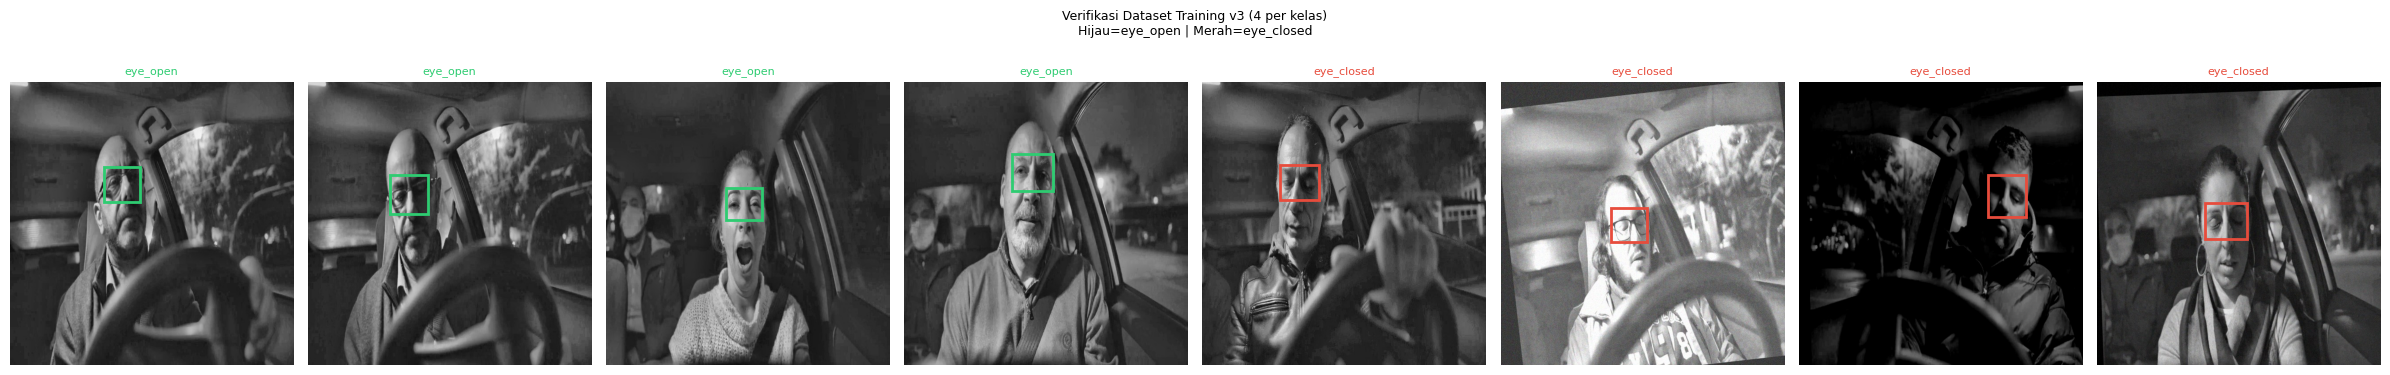

In [15]:
# ============================================================
# FASE 4-A: Verifikasi final sebelum training
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2, random, os
from pathlib import Path

def verify_training_set(img_dir, lbl_dir, n_per_class=4, title=''):
    COLORS = {0:'#2ECC71', 1:'#E74C3C'}
    NAMES  = ['eye_open','eye_closed']

    by_cls = {0:[],1:[]}
    for ip in Path(img_dir).glob('*.jpg'):
        lp = Path(lbl_dir)/(ip.stem+'.txt')
        if not lp.exists(): continue
        line = open(lp).readline().strip()
        if not line: continue
        c = int(float(line.split()[0]))  # FIX
        if c in by_cls: by_cls[c].append(ip)

    print(f'Distribusi training set final:')
    total = sum(len(v) for v in by_cls.values())
    for c,lst in by_cls.items():
        print(f'  {NAMES[c]}: {len(lst)} ({len(lst)/total*100:.1f}%)')
    print(f'  Rasio: {len(by_cls[0])/max(len(by_cls[1]),1):.1f}:1')

    samples = []
    for c in [0,1]:
        n = min(n_per_class, len(by_cls[c]))
        samples += [(ip,c) for ip in random.sample(by_cls[c],n)]

    if not samples: return
    fig, axes = plt.subplots(1, len(samples), figsize=(len(samples)*3,4))
    if len(samples)==1: axes=[axes]

    for i,(ip,gt_cls) in enumerate(samples):
        img = cv2.imread(str(ip))
        if img is None: continue
        img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        h,w = img.shape[:2]
        lp  = Path(lbl_dir)/(ip.stem+'.txt')
        axes[i].imshow(img_rgb)

        for line in open(lp):
            parts = line.strip().split()
            if len(parts)<5: continue
            c = int(float(parts[0]))
            cx,cy,bw,bh = [float(x) for x in parts[1:]]
            x1 = (cx-bw/2)*w; y1 = (cy-bh/2)*h
            rect = mpatches.Rectangle((x1,y1),bw*w,bh*h,
                linewidth=2,edgecolor=COLORS.get(c,'y'),facecolor='none')
            axes[i].add_patch(rect)
        axes[i].set_title(NAMES[gt_cls],fontsize=8,
                          color=COLORS.get(gt_cls,'y'))
        axes[i].axis('off')

    plt.suptitle(f'{title}\nHijau=eye_open | Merah=eye_closed',fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR,'verify_training_v3.png'),
                dpi=100,bbox_inches='tight')
    plt.show()


ni = len(list(Path(DIRS['dataset_train']).glob('*')))
nv = len(list(Path(DIRS['dataset_val']).glob('*')))
nt = len(list(Path(DIRS['dataset_test']).glob('*')))
print(f'Train: {ni} | Val: {nv} | Test: {nt}')
if ni > 0:
    verify_training_set(DIRS['dataset_train'], DIRS['labels_train'],
                         n_per_class=4,
                         title='Verifikasi Dataset Training v3 (4 per kelas)')


In [16]:
# ============================================================

# FASE 4-B: Training YOLOv11n

# FIX: imgsz=640 (full frame), class weights, epochs=150

# ============================================================

import os

from ultralytics import YOLO

import torch

from pathlib import Path



if 'data_yaml_path' not in globals() or not os.path.exists(data_yaml_path):

    data_yaml_path = os.path.join(BASE_DIR,'dataset_v3','data.yaml')

if 'BEST_MODEL_PATH' not in globals():

    BEST_MODEL_PATH = os.path.join(DIRS['models'],'drowsy_eye_v3','weights','best.pt')



if not os.path.exists(data_yaml_path):

    raise FileNotFoundError('data.yaml tidak ada.')



print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')

if torch.cuda.is_available():

    vram = torch.cuda.get_device_properties(0).total_memory/1e9

    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {vram:.1f}GB')

    # Sesuaikan batch size dengan VRAM

    batch = 8 if vram < 5 else (16 if vram < 8 else 32)

    print(f'Auto batch: {batch}')



# Hitung class weights dari training set

counts = {0:0, 1:0}

for lp in Path(DIRS['labels_train']).glob('*.txt'):

    line = open(lp).readline().strip()

    if not line: continue

    c = int(float(line.split()[0]))

    if c in counts: counts[c]+=1

total = sum(counts.values())

print(f'\nDistribusi training: eye_open={counts[0]} ({counts[0]/total*100:.1f}%) '

      f'eye_closed={counts[1]} ({counts[1]/total*100:.1f}%)')



# cls weight = rasio untuk focal loss kompensasi

cls_weight = (counts[0]/max(counts[1],1)) ** 0.5  # sqrt untuk smoothing

print(f'cls weight untuk eye_closed: {cls_weight:.3f}')



model = YOLO(CONFIG['model_size'])

print('\nTraining dimulai...')



results = model.train(

    data          = data_yaml_path,

    epochs        = 100,

    batch         = batch,

    imgsz         = 640,      # FIX: 640 untuk full-frame detection

    patience      = 30,

    lr0           = 0.001,

    lrf           = 0.01,

    workers       = CONFIG['workers'],

    device        = 0 if torch.cuda.is_available() else 'cpu',

    project       = DIRS['models'],

    name          = 'drowsy_eye_v3',

    exist_ok      = True,



    # Class weight untuk focal loss kompensasi imbalance

    cls           = cls_weight,



    # Augmentasi untuk full frame detection

    hsv_h         = 0.0,   # Grayscale

    hsv_s         = 0.0,   # Grayscale

    hsv_v         = 0.3,   # Brightness

    degrees       = 8.0,

    translate     = 0.05,

    scale         = 0.3,

    flipud        = 0.0,

    fliplr        = 0.5,

    mosaic        = 0.5,

    mixup         = 0.0,

    copy_paste    = 0.0,



    optimizer     = 'AdamW',

    cos_lr        = True,

    weight_decay  = 0.0005,

    warmup_epochs = 5,



    save          = True,

    save_period   = 10,

    cache         = 'ram',

    plots         = True,

    verbose       = True,

)



BEST_MODEL_PATH = os.path.join(DIRS['models'],'drowsy_eye_v3','weights','best.pt')

print(f'\nTraining selesai! Model: {BEST_MODEL_PATH}')

print(f'Ada: {os.path.exists(BEST_MODEL_PATH)}')

PyTorch: 2.5.1+cu121 | CUDA: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU | VRAM: 4.3GB
Auto batch: 8

Distribusi training: eye_open=9222 (47.1%) eye_closed=10345 (52.9%)
cls weight untuk eye_closed: 0.944

Training dimulai...


C:\Users\ACER\miniconda3\envs\drowsy_detection\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.9441637265755114, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\ACER\drowsy_detection\dataset_v3\data.yaml, degrees=8.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, 

In [7]:
from ultralytics import YOLO
import os

# 1. Muat model dari checkpoint terbaik yang tersimpan
model_path = os.path.join(DIRS['models'], 'drowsy_eye_v3', 'weights', 'best.pt')
model = YOLO(model_path)

print("Mengevaluasi model terbaik (best.pt)...")

# 2. Jalankan validasi untuk mendapatkan laporan performa (map50, precision, recall)
metrics = model.val(data=data_yaml_path)

# 3. Export model ke format yang diinginkan (misal .onnx untuk deployment)
model.export(format='onnx')

print("Selesai! Anda sekarang menggunakan best.pt sebagai model final.")

Mengevaluasi model terbaik (best.pt)...
Ultralytics 8.4.37  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 47.715.7 MB/s, size: 61.8 KB)
val: Scanning C:\Users\ACER\drowsy_detection\dataset_v3\labels\val.cache... 3162 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3162/3162  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 198/198 5.1it/s 39.1s0.2ss
                   all       3162       3162      0.969       0.96       0.99      0.904
              eye_open       2635       2635      0.981      0.969      0.993      0.903
            eye_closed        527        527      0.957      0.951      0.987      0.905
Speed: 1.9ms preprocess, 4.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to C:\Users\ACER\runs\detect\val13
Ultralytics

In [8]:
# ============================================================
# MAR ENGINE — Sesuai jurnal Florez et al. (2024)
#
# MAR = (||P2-P8|| + ||P3-P7|| + ||P4-P6||) / (3 * ||P5-P1||)
# Threshold: MAR > 55 selama >= 5 detik = menguap
#
# Digabung dengan:
# - Alert instan: drowsiness conf > 95% AND closed > 300ms
# - PERCLOS: rolling window 60 detik (long-term trend)
# ============================================================

import time
from collections import deque
from dataclasses import dataclass, field
from typing import Optional


@dataclass
class AlertEvent:
    timestamp     : float
    alert_type    : str    # 'microsleep' | 'yawning' | 'perclos_l1' | 'perclos_l2' | 'perclos_l3'
    level         : int    # 1, 2, 3
    metric_value  : float  # PERCLOS value atau MAR value
    conf_value    : float  # Confidence model
    driver_id     : str = ''
    vehicle_id    : str = ''

    def to_dict(self):
        return {
            'timestamp'   : self.timestamp,
            'datetime'    : time.strftime('%Y-%m-%d %H:%M:%S',
                                          time.localtime(self.timestamp)),
            'alert_type'  : self.alert_type,
            'level'       : self.level,
            'metric_value': round(self.metric_value, 4),
            'conf_value'  : round(self.conf_value, 4),
            'driver_id'   : self.driver_id,
            'vehicle_id'  : self.vehicle_id,
        }


class DrowsinessAlertEngine:
    """
    Gabungan tiga lapisan deteksi sesuai jurnal:

    Layer 1 — INSTAN (per frame):
      Jika confidence model eye_closed > 95%
      DAN durasi mata tertutup > 300ms → Alert Level 1 (microsleep)

    Layer 2 — MAR (per frame, kumulatif):
      Jika MAR > 55 selama >= 5 detik → Alert Level 2 (yawning)

    Layer 3 — PERCLOS (rolling 60 detik):
      PERCLOS > 50% → Level 1 | > 70% → Level 2 | > 85% → Level 3
    """

    # Sesuai jurnal
    DROWSY_CONF_THRESHOLD  = 0.95     # > 95% confidence
    CLOSED_DURATION_MS     = 300      # > 300ms mata tertutup = microsleep
    MAR_THRESHOLD          = 55.0     # MAR > 55
    MAR_DURATION_SEC       = 5.0      # > 5 detik = yawning

    def __init__(self, fps=30, window_sec=60,
                 perclos_l1=0.50, perclos_l2=0.70, perclos_l3=0.85,
                 driver_id='', vehicle_id=''):
        self.fps           = fps
        self.window_size   = fps * window_sec
        self.window        = deque(maxlen=self.window_size)
        self.thresholds    = [perclos_l1, perclos_l2, perclos_l3]
        self.driver_id     = driver_id
        self.vehicle_id    = vehicle_id

        # Layer 1: instant microsleep counter
        self.closed_start_time  = None
        self.microsleep_alerted = False

        # Layer 2: MAR yawning counter
        self.yawn_start_time    = None
        self.yawn_alerted       = False

        # Alert history
        self.alert_history      = []
        self.last_alert_ts      = 0
        self.alert_cooldown_sec = 5

        # Stats
        self.total_frames       = 0
        self.session_start      = time.time()

    @property
    def perclos(self):
        valid = [f for f in self.window if f != -1]
        if not valid: return 0.0
        return sum(valid) / len(valid)

    @property
    def window_fill_pct(self):
        return len(self.window) / self.window_size * 100

    def update(self, is_closed: Optional[bool],
               conf: float = 0.0,
               mar_value: float = 0.0,
               timestamp: float = None) -> Optional[AlertEvent]:
        """
        Update engine per frame.

        Args:
            is_closed  : True=closed | False=open | None=no detect
            conf       : Confidence dari model YOLO untuk eye_closed
            mar_value  : MAR value dari compute_mar()
            timestamp  : Unix timestamp (None = now)

        Returns:
            AlertEvent jika ada alert baru, None jika tidak
        """
        ts = timestamp or time.time()
        self.total_frames += 1

        # ── Tambah ke PERCLOS window ──
        if is_closed is None:
            self.window.append(-1)
            self.closed_start_time = None
            self.microsleep_alerted = False
        else:
            self.window.append(1 if is_closed else 0)

        # ────────────────────────────────────────────
        # LAYER 1: Instant microsleep (sesuai jurnal)
        # ────────────────────────────────────────────
        if is_closed and conf >= self.DROWSY_CONF_THRESHOLD:
            if self.closed_start_time is None:
                self.closed_start_time = ts

            elapsed_ms = (ts - self.closed_start_time) * 1000

            if elapsed_ms >= self.CLOSED_DURATION_MS and not self.microsleep_alerted:
                self.microsleep_alerted = True
                event = AlertEvent(
                    timestamp    = ts,
                    alert_type   = 'microsleep',
                    level        = 2,
                    metric_value = elapsed_ms / 1000,
                    conf_value   = conf,
                    driver_id    = self.driver_id,
                    vehicle_id   = self.vehicle_id,
                )
                self.alert_history.append(event)
                return event
        else:
            self.closed_start_time  = None
            self.microsleep_alerted = False

        # ────────────────────────────────────────────
        # LAYER 2: MAR yawning (sesuai jurnal)
        # ────────────────────────────────────────────
        if mar_value > self.MAR_THRESHOLD:
            if self.yawn_start_time is None:
                self.yawn_start_time = ts

            elapsed_sec = ts - self.yawn_start_time

            if elapsed_sec >= self.MAR_DURATION_SEC and not self.yawn_alerted:
                self.yawn_alerted = True
                event = AlertEvent(
                    timestamp    = ts,
                    alert_type   = 'yawning',
                    level        = 1,
                    metric_value = mar_value,
                    conf_value   = mar_value / 100,
                    driver_id    = self.driver_id,
                    vehicle_id   = self.vehicle_id,
                )
                self.alert_history.append(event)
                return event
        else:
            self.yawn_start_time = None
            self.yawn_alerted    = False

        # ────────────────────────────────────────────
        # LAYER 3: PERCLOS rolling window
        # ────────────────────────────────────────────
        if self.window_fill_pct < 30:
            return None  # Window belum cukup terisi

        p = self.perclos
        new_level = 0
        for i, thr in enumerate(reversed(self.thresholds)):
            if p >= thr:
                new_level = 3 - i
                break

        if new_level > 0 and (ts - self.last_alert_ts) > self.alert_cooldown_sec:
            self.last_alert_ts = ts
            event = AlertEvent(
                timestamp    = ts,
                alert_type   = f'perclos_l{new_level}',
                level        = new_level,
                metric_value = p,
                conf_value   = p,
                driver_id    = self.driver_id,
                vehicle_id   = self.vehicle_id,
            )
            self.alert_history.append(event)
            return event

        return None

    def get_status(self):
        return {
            'perclos'      : round(self.perclos, 3),
            'window_pct'   : round(self.window_fill_pct, 1),
            'total_alerts' : len(self.alert_history),
        }


# ── TEST ENGINE ──
print('Test DrowsinessAlertEngine...')
engine = DrowsinessAlertEngine(
    fps=30, window_sec=60,
    perclos_l1=0.50, perclos_l2=0.70, perclos_l3=0.85,
    driver_id='DRV_001', vehicle_id='BUS_001'
)

# Simulasi: mata tertutup 350ms dengan conf > 95% → trigger Layer 1
print('\nSimulasi Layer 1 (microsleep 350ms):')
for i in range(11):  # 11 frame @ 30fps = ~367ms
    ts = time.time() - (0.367 - i * 0.033)
    alert = engine.update(is_closed=True, conf=0.97, mar_value=20.0, timestamp=ts)
    if alert:
        print(f'  ALERT: {alert.alert_type} | Level {alert.level} | '
              f'{alert.metric_value:.3f}s closed')

# Simulasi: MAR > 55 selama 6 detik → trigger Layer 2
print('\nSimulasi Layer 2 (yawning 6 detik):')
engine2 = DrowsinessAlertEngine(fps=30)
for i in range(181):  # 181 frame @ 30fps = ~6 detik
    ts     = time.time() - (6.0 - i * 0.033)
    alert  = engine2.update(is_closed=False, conf=0.5, mar_value=65.0, timestamp=ts)
    if alert:
        print(f'  ALERT: {alert.alert_type} | Level {alert.level} | '
              f'MAR={alert.metric_value:.1f}')

print('\nEngine test selesai.')


Test DrowsinessAlertEngine...

Simulasi Layer 1 (microsleep 350ms):
  ALERT: microsleep | Level 2 | 0.330s closed

Simulasi Layer 2 (yawning 6 detik):
  ALERT: yawning | Level 1 | MAR=65.0

Engine test selesai.


## FASE 5 — Evaluasi Model
---

In [9]:
# ============================================================
# FASE 5-A: Evaluasi standar YOLO
# ============================================================
import os
from ultralytics import YOLO
import torch

if 'BEST_MODEL_PATH' not in globals():
    BEST_MODEL_PATH = os.path.join(DIRS['models'],'drowsy_eye_v3','weights','best.pt')
if 'data_yaml_path' not in globals():
    data_yaml_path  = os.path.join(BASE_DIR,'dataset_v3','data.yaml')

if not os.path.exists(BEST_MODEL_PATH):
    print('Model belum ada. Jalankan training dahulu.')
else:
    m = YOLO(BEST_MODEL_PATH)
    print('Evaluasi TEST SET...')
    metrics = m.val(
        data  = data_yaml_path,
        split = 'test',
        imgsz = 640,
        conf  = 0.25,
        iou   = 0.50,
        device= 0 if torch.cuda.is_available() else 'cpu',
        plots = True,
    )
    print('\n=== HASIL EVALUASI v3 ===')
    print(f'mAP50     : {metrics.box.map50:.4f}')
    print(f'mAP50-95  : {metrics.box.map:.4f}')
    print(f'Precision : {metrics.box.mp:.4f}')
    print(f'Recall    : {metrics.box.mr:.4f}')
    print('Per Kelas:')
    for i,cn in enumerate(['eye_open','eye_closed']):
        if i < len(metrics.box.ap50):
            print(f'  {cn}: AP50={metrics.box.ap50[i]:.4f}')
    for name,val,tgt in [('mAP50',metrics.box.map50,0.70),
                          ('Recall',metrics.box.mr,0.75)]:
        icon = 'OK' if val>=tgt else '!!'
        print(f'  [{icon}] {name}: {val:.4f} (target>{tgt})')


Evaluasi TEST SET...
Ultralytics 8.4.37  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 58.914.0 MB/s, size: 65.3 KB)
val: Scanning C:\Users\ACER\drowsy_detection\dataset_v3\labels\test.cache... 1582 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1582/1582  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 99/99 4.5it/s 22.0s0.2ss
                   all       1582       1582      0.949      0.954      0.953      0.869
              eye_open       1318       1318      0.974      0.962      0.973      0.878
            eye_closed        264        264      0.924      0.947      0.932      0.861
Speed: 2.1ms preprocess, 4.7ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to C:\Users\ACER\runs\detect\val14

=== HASIL EVALUASI v3 ===
mAP5

In [11]:
# ============================================================
# FASE 5-B: Confusion Matrix + Classification Report + ROC Curve
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, torch
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc
)

if 'BEST_MODEL_PATH' not in globals():
    BEST_MODEL_PATH = os.path.join(DIRS['models'],'drowsy_eye_v3','weights','best.pt')

if not os.path.exists(BEST_MODEL_PATH):
    print('Model belum ada.')
else:
    DEVICE = 0 if torch.cuda.is_available() else 'cpu'
    m = YOLO(BEST_MODEL_PATH)
    CN = ['eye_open','eye_closed']

    test_imgs = (list(Path(DIRS['dataset_test']).glob('*.jpg')))
    y_true, y_pred, y_score = [], [], []

    print(f'Inferensi {len(test_imgs)} test images...')
    for ip in test_imgs:
        lp = Path(DIRS['labels_test'])/(ip.stem+'.txt')
        if not lp.exists(): continue
        line = open(lp).readline().strip()
        if not line: continue
        gt = int(float(line.split()[0]))  # FIX

        res = m.predict(source=str(ip),conf=0.10,verbose=False,device=DEVICE)
        boxes = res[0].boxes if res else None

        if boxes is None or len(boxes)==0:
            # Tidak ada deteksi = model tidak yakin = default eye_open
            pc, pconf = 0, 0.0
        else:
            bi    = boxes.conf.argmax()
            pc    = int(boxes.cls[bi].item())
            pconf = float(boxes.conf[bi].item())

        y_true.append(gt); y_pred.append(pc)
        y_score.append(pconf if pc==1 else 1.0-pconf)

    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_score = np.array(y_score)
    print(f'Total: {len(y_true)} sampel')

    # ── Classification Report ──
    print('\n=== CLASSIFICATION REPORT ===')
    print(classification_report(y_true,y_pred,target_names=CN,digits=4))

    # ── Confusion Matrix ──
    cm = confusion_matrix(y_true,y_pred)
    fig,axes = plt.subplots(1,2,figsize=(12,5))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
                xticklabels=CN,yticklabels=CN,ax=axes[0])
    axes[0].set_title('Confusion Matrix (Count)'); axes[0].set_ylabel('GT'); axes[0].set_xlabel('Pred')
    cm_n = cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
    sns.heatmap(cm_n,annot=True,fmt='.3f',cmap='Blues',
                xticklabels=CN,yticklabels=CN,ax=axes[1])
    axes[1].set_title('Confusion Matrix (Normalized)'); axes[1].set_ylabel('GT'); axes[1].set_xlabel('Pred')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR,'confusion_matrix_v3.png'),dpi=120,bbox_inches='tight')
    plt.show()

    # ── ROC Curve ──
    if len(np.unique(y_true)) > 1:
        fpr,tpr,thr = roc_curve(y_true,y_score,pos_label=1)
        roc_auc = auc(fpr,tpr)
        j_opt = np.argmax(tpr-fpr)
        fig,ax = plt.subplots(figsize=(8,6))
        ax.plot(fpr,tpr,color='#2980B9',lw=2,
                label=f'ROC (AUC={roc_auc:.4f})')
        ax.plot([0,1],[0,1],'k--',lw=1)
        ax.scatter([fpr[j_opt]],[tpr[j_opt]],color='#E74C3C',s=100,zorder=5,
                   label=f'Optimal thr={thr[j_opt]:.3f} TPR={tpr[j_opt]:.3f}')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title('ROC Curve — eye_closed (Drowsy) Detection')
        ax.legend(loc='lower right'); ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(BASE_DIR,'roc_v3.png'),dpi=120,bbox_inches='tight')
        plt.show()
        print(f'\nAUC-ROC: {roc_auc:.4f}')

    # ── Ringkasan ──
    tp = cm[1,1]; fn = cm[1,0]; fp = cm[0,1]; tn = cm[0,0]
    print('\n=== RINGKASAN METRIK v3 ===')
    print(f'Accuracy         : {np.mean(y_true==y_pred):.4f}')
    print(f'Sensitivity (TPR): {tp/(tp+fn+1e-9):.4f}  <- paling penting safety')
    print(f'Specificity      : {tn/(tn+fp+1e-9):.4f}')
    print(f'TP={tp} FP={fp} TN={tn} FN={fn}')
    if fn > fp:
        print('!! FN > FP: model masih sering miss eye_closed')
        print('   → Pertimbangkan turunkan conf threshold di predict(conf=0.10→0.05)')


Inferensi 1582 test images...
Total: 1582 sampel

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    eye_open     0.9871    0.9848    0.9859      1318
  eye_closed     0.9251    0.9356    0.9303       264

    accuracy                         0.9766      1582
   macro avg     0.9561    0.9602    0.9581      1582
weighted avg     0.9767    0.9766    0.9767      1582



<Figure size 1200x500 with 4 Axes>

<Figure size 800x600 with 1 Axes>


AUC-ROC: 0.9917

=== RINGKASAN METRIK v3 ===
Accuracy         : 0.9766
Sensitivity (TPR): 0.9356  <- paling penting safety
Specificity      : 0.9848
TP=247 FP=20 TN=1298 FN=17


In [12]:
import cv2
import numpy as np
from ultralytics import YOLO
import mediapipe as mp
from collections import deque
import time
import os

# ── Load Model ──
model_path = os.path.join(DIRS['models'], 'drowsy_eye_v3', 'weights', 'best.pt')
model = YOLO(model_path)

mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(
    model_selection=1,             # FIX: 1 = Full-Range model (deteksi hingga 5 meter)
    min_detection_confidence=0.35  # FIX: Turunkan sedikit dari 0.5 agar toleran di jarak jauh
)

CONF_THRESHOLD   = 0.40 # Turunkan sedikit karena gambar dari jauh lebih ngeblur
TEMPORAL_WINDOW  = 15
ALERT_RATIO      = 0.55

# ── PARAMETER NORMALISASI SKALA (KUNCI PERBAIKAN) ──
TARGET_FACE_SIZE = 350  # Ukuran rata-rata wajah pada dataset pelatihan (NITYMed)
YOLO_INPUT_SIZE  = 640  # Ukuran input absolut YOLO

def get_eye_decision(results, conf_threshold):
    best_closed_conf = 0.0
    best_open_conf   = 0.0

    for r in results:
        for box in r.boxes:
            cls = int(box.cls.item())
            conf = float(box.conf.item())
            if cls == 1 and conf > best_closed_conf: best_closed_conf = conf
            elif cls == 0 and conf > best_open_conf: best_open_conf = conf

    # Duel Probabilitas
    if best_open_conf > best_closed_conf and best_open_conf >= conf_threshold:
        return False, best_open_conf
    if best_closed_conf >= conf_threshold:
        return True, best_closed_conf
    return False, max(best_open_conf, best_closed_conf)

class TemporalSmoother:
    def __init__(self, window=15, alert_ratio=0.55):
        self.window = deque(maxlen=window)
        self.alert_ratio = alert_ratio
    def update(self, is_closed: bool):
        self.window.append(1 if is_closed else 0)
        fill_pct = len(self.window) / self.window.maxlen * 100
        if fill_pct < 40: return False, 0.0, fill_pct
        ratio = sum(self.window) / len(self.window)
        return ratio >= self.alert_ratio, ratio, fill_pct

smoother = TemporalSmoother(window=TEMPORAL_WINDOW, alert_ratio=ALERT_RATIO)
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

while cap.isOpened():
    success, frame = cap.read()
    if not success: break
    
    display = frame.copy()
    h_frame, w_frame, _ = frame.shape
    
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    face_results = face_detector.process(rgb_frame)
    
    alert = False
    ratio = 0.0
    conf = 0.0
    fill_pct = 0.0
    
    if face_results.detections:
        detection = face_results.detections[0]
        bboxC = detection.location_data.relative_bounding_box
        
        xmin = int(bboxC.xmin * w_frame)
        ymin = int(bboxC.ymin * h_frame)
        w_box = int(bboxC.width * w_frame)
        h_box = int(bboxC.height * h_frame)
        
        size = max(w_box, h_box)
        center_x = xmin + w_box // 2
        center_y = ymin + int(h_box * 0.35) 
        
        pad_size = int(size * 1.6) 
        half_pad = pad_size // 2
        
        x1 = center_x - half_pad
        y1 = center_y - half_pad
        x2 = center_x + half_pad
        y2 = center_y + half_pad
        
        crop_square = np.zeros((pad_size, pad_size, 3), dtype=np.uint8)
        
        src_x1 = max(0, x1)
        src_y1 = max(0, y1)
        src_x2 = min(w_frame, x2)
        src_y2 = min(h_frame, y2)
        
        dst_x1 = src_x1 - x1
        dst_y1 = src_y1 - y1
        dst_x2 = dst_x1 + (src_x2 - src_x1)
        dst_y2 = dst_y1 + (src_y2 - src_y1)
        
        if src_x2 > src_x1 and src_y2 > src_y1:
            crop_square[dst_y1:dst_y2, dst_x1:dst_x2] = frame[src_y1:src_y2, src_x1:src_x2]
            
            # --- FIX 2: ALGORITMA INTERPOLASI UNTUK WAJAH KECIL ---
            # Jika wajah terlalu kecil (dari jauh), gunakan INTER_CUBIC untuk mempertahankan 
            # ketajaman bentuk kelopak mata saat dibesarkan ke 350x350.
            if pad_size < TARGET_FACE_SIZE:
                interp_method = cv2.INTER_CUBIC
            else:
                interp_method = cv2.INTER_AREA

            face_resized = cv2.resize(crop_square, (TARGET_FACE_SIZE, TARGET_FACE_SIZE), interpolation=interp_method)
            
            gray_face = cv2.cvtColor(face_resized, cv2.COLOR_BGR2GRAY)
            gray3_face = cv2.merge([gray_face, gray_face, gray_face])
            
            canvas = np.zeros((YOLO_INPUT_SIZE, YOLO_INPUT_SIZE, 3), dtype=np.uint8)
            start_idx = (YOLO_INPUT_SIZE - TARGET_FACE_SIZE) // 2
            end_idx = start_idx + TARGET_FACE_SIZE
            canvas[start_idx:end_idx, start_idx:end_idx] = gray3_face
            
            # Inferensi YOLO
            yolo_results = model.predict(canvas, conf=CONF_THRESHOLD, imgsz=640, verbose=False)
            is_closed, conf = get_eye_decision(yolo_results, CONF_THRESHOLD)
            alert, ratio, fill_pct = smoother.update(is_closed)
            
            # --- DEBUG VISION ---
            debug_canvas = canvas.copy()
            for r in yolo_results:
                for box in r.boxes:
                    bx1, by1, bx2, by2 = map(int, box.xyxy[0].tolist())
                    bcls = int(box.cls.item())
                    bcolor = (0, 0, 255) if bcls == 1 else (0, 255, 0)
                    cv2.rectangle(debug_canvas, (bx1, by1), (bx2, by2), bcolor, 2)
            
            debug_view = cv2.resize(debug_canvas, (180, 180))
            display[10:190, w_frame-190:w_frame-10] = debug_view
            cv2.putText(display, "YOLO Vision", (w_frame-185, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,255), 1)

            disp_x1, disp_y1 = max(0, x1), max(0, y1)
            disp_x2, disp_y2 = min(w_frame, x2), min(h_frame, y2)
            box_color = (0, 0, 255) if alert else ((0, 165, 255) if ratio>0.3 else (0, 255, 0))
            cv2.rectangle(display, (disp_x1, disp_y1), (disp_x2, disp_y2), box_color, 2)
            
    else:
        cv2.putText(display, "WAJAH TIDAK TERDETEKSI", (50, 200), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)
    # ── UI Status Panel ──
    panel_h = 75
    cv2.rectangle(display, (0,0), (display.shape[1], panel_h), (0,0,0), -1)
    
    if alert:
        status = "!!! BAHAYA: MENGANTUK !!!"
        text_color = (0, 0, 255)
    elif ratio > 0.3 and fill_pct >= 40:
        status = "PERHATIAN: MULAI MENGANTUK"
        text_color = (0, 165, 255)
    else:
        status = "MATA TERBUKA"
        text_color = (0, 255, 0)

    cv2.putText(display, status, (10, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.0, text_color, 2)
    cv2.imshow("Smart Driver Monitor v4", display)

    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()

C:\Users\ACER\miniconda3\envs\drowsy_detection\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
